This notebook is exploratory. The goal is to experiment with charts to get an overview of the data and find more questions to base additional calculations off of.  
END OF DAY 1 NOTE: Need to find the year range for the data. Need to explore average by industry bar chart to see if that is counting any level of AI adoption and look at risk management score column

In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3


In [3]:
#Create dataframes
df_industry = pd.read_csv("../Data/ai_industry_summary.csv") 

In [4]:
df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

In [5]:
df_country = pd.read_csv("../Data/country_ai_index.csv")

Text(0, 0.5, 'Average AI Adoption %')

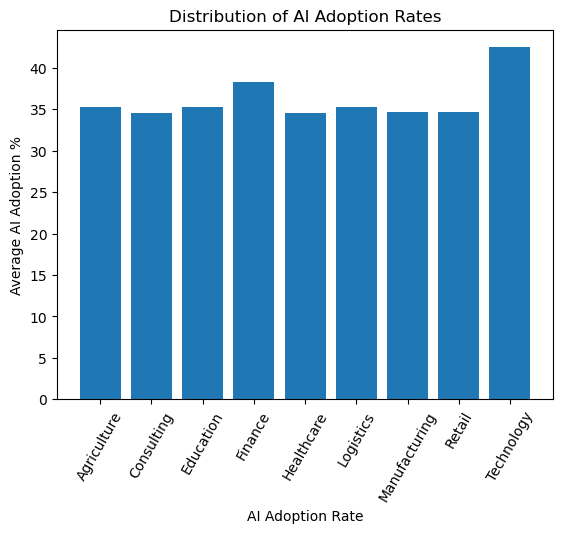

In [ ]:
# Plot bar chart of AI Adoption Rates by Industry #Note: need to explore data more to see if it means any level of AI adoption
plt.bar(df_industry['industry'], df_industry["avg_ai_adoption_rate"])
plt.title("Distribution of AI Adoption Rates")
plt.xticks(rotation=60)
plt.xlabel("AI Adoption Rate")
plt.ylabel("Average AI Adoption %")

The bar chart above answers the question of how 

In [7]:
# Group by country and industry and then focus in on the ai adoption rate .mean()
country_industry = (
    df_company
    .groupby(["country", "industry"])["ai_adoption_rate"]
    .mean()
    .reset_index()
)

country_industry.head()

,country,industry,ai_adoption_rate
0,Argentina,Agriculture,32.432380
1,Argentina,Consulting,36.357964
2,Argentina,Education,30.827514
3,Argentina,Finance,38.770831
4,Argentina,Healthcare,30.699859


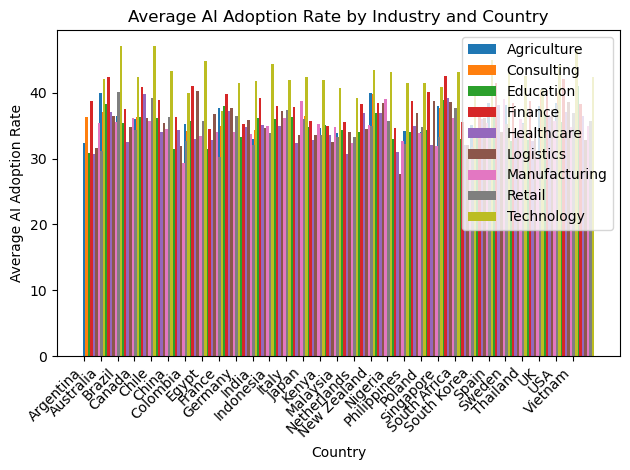

In [8]:
# DO NOT USE
# This ended up not being a great chart because there are too many bars
import matplotlib.pyplot as plt
import numpy as np

countries = country_industry["country"].unique()
industries = country_industry["industry"].unique()

x = np.arange(len(countries))

width = 0.15

for i, industry in enumerate(industries):
    
    data = country_industry[
        country_industry["industry"] == industry
    ]

    plt.bar(
        x + i * width,
        data["ai_adoption_rate"],
        width,
        label=industry
    )

plt.xticks(
    x,
    countries,
    rotation=45,
    ha="right"
)

plt.xlabel("Country")
plt.ylabel("Average AI Adoption Rate")
plt.title("Average AI Adoption Rate by Industry and Country")

plt.legend()
plt.tight_layout()

plt.show()

In [9]:
heatmap_data = df_company.pivot_table(
    index="country",
    columns="industry",
    values="ai_adoption_rate",
    aggfunc="mean"
)

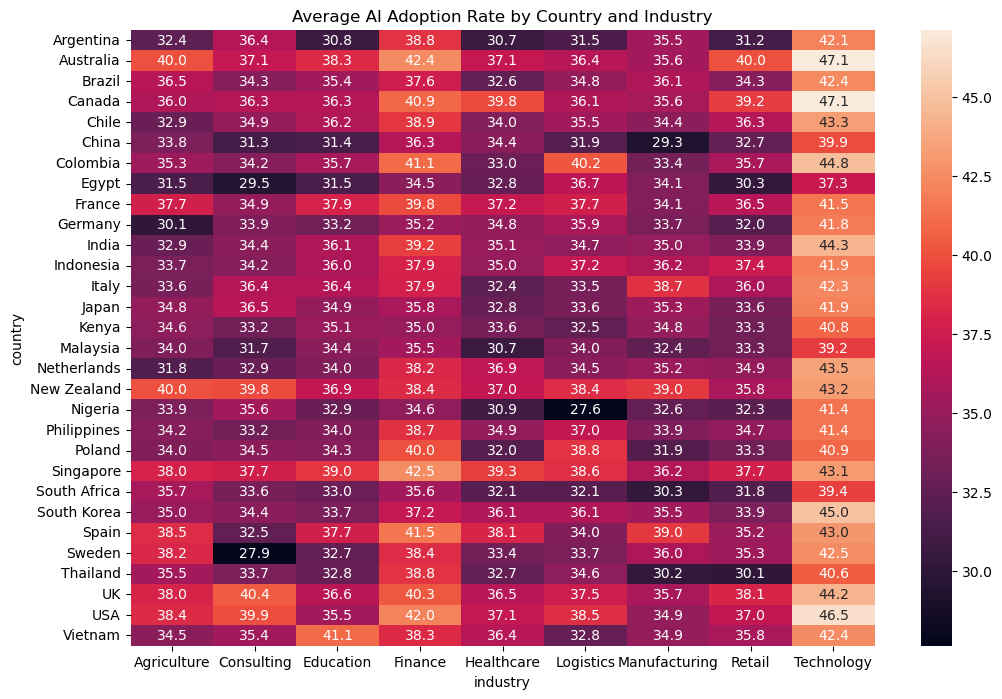

In [10]:
# Do not Use. Too overwhelming to look at
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Average AI Adoption Rate by Country and Industry")

plt.show()

In [11]:
#calculation for choropleth
country_ai = (
    df_company
    .groupby("country")["ai_adoption_rate"]
    .mean()
    .reset_index()
)

country_ai.head()

,country,ai_adoption_rate
0,Argentina,34.327419
1,Australia,39.933564
2,Brazil,36.674198
3,Canada,39.120333
4,Chile,36.461705


In [12]:
# USE THIS BUT ADD MORE DETAIL
# Choropleth of world AI adoption
import plotly.express as px

fig = px.choropleth(
    country_ai,
    locations="country",
    locationmode="country names",
    color="ai_adoption_rate",
    hover_name="country",
    title="Global Average AI Adoption Rate"
)

fig.show()

C:\Users\patri\AppData\Local\Temp\ipykernel_51236\1761818179.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


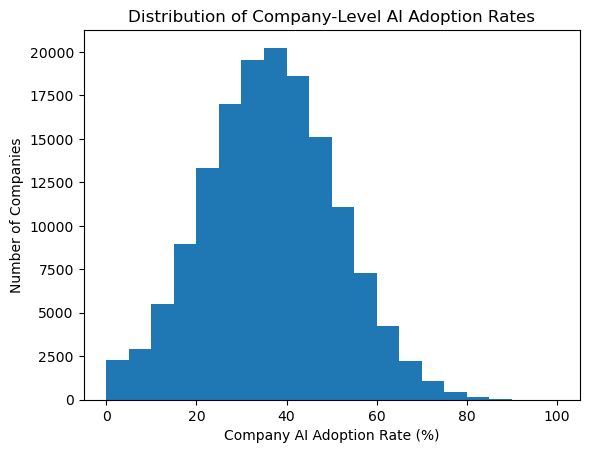

In [13]:
plt.hist(
    df_company["ai_adoption_rate"],
    bins=20
)

plt.xlabel("Company AI Adoption Rate (%)")
plt.ylabel("Number of Companies")
plt.title("Distribution of Company-Level AI Adoption Rates")

plt.show()

The above histogram shows us the distribution of company-level AI adoption rates. The bins are telling us what percentage of a company's workflows have been touched by AI. The y axis is the number of companies. 

In [14]:
#Shows how many companies sit at the different levels of AI adoption
stage_counts= df_company["ai_adoption_stage"].value_counts()

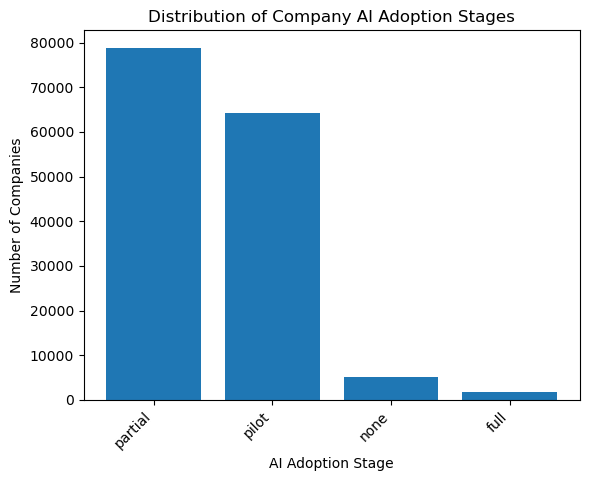

In [15]:
plt.bar(
    stage_counts.index,
    stage_counts.values
)

plt.title("Distribution of Company AI Adoption Stages")
plt.xlabel("AI Adoption Stage")
plt.ylabel("Number of Companies")

plt.xticks(rotation=45, ha="right")

plt.show()

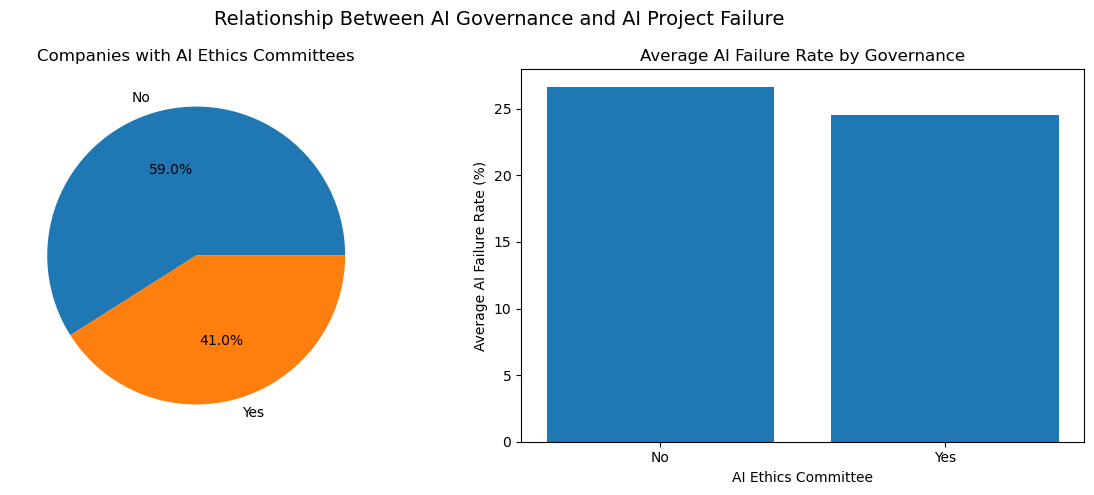

In [ ]:
import matplotlib.pyplot as plt

# Count companies with/without AI ethics committee
committee_counts = df_company["ai_ethics_committee"].value_counts()

# Average AI failure rate by committee status
committee_failure = (
    df_company
    .groupby("ai_ethics_committee")["ai_failure_rate"]
    .mean()
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)


# LEFT: Pie chart
axes[0].pie(
    committee_counts,
    labels=committee_counts.index,
    autopct="%1.1f%%"
)

axes[0].set_title(
    "Companies with AI Ethics Committees"
)


# RIGHT: Failure 
axes[1].bar(
    committee_failure.index,
    committee_failure.values
)

axes[1].set_title(
    "Average AI Failure Rate by Governance"
)

axes[1].set_xlabel(
    "AI Ethics Committee"
)

axes[1].set_ylabel(
    "Average AI Failure Rate (%)"
)


# Main title
fig.suptitle(
    "Relationship Between AI Governance and AI Project Failure",
    fontsize=14
)

plt.tight_layout()

plt.show()

Above You can see that AI governance and project failure does not looks very significant. This makes me want to do a correlation matrix.


In [ ]:
# I want to merge country to company for the correlation
ai_analysis = df_company.merge(
    df_country,
    on=["country", "region"],
    how="left"
)

ai_analysis.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,innovation_score,customer_satisfaction,survey_source,data_collection_method,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,53,5.20,WEF Survey,API Scrape,39436.63,86.01,75.65,Moderate,2234,296.83
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,51,6.98,McKinsey Report,Phone Interview,39436.63,86.01,75.65,Moderate,2234,296.83
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,40,4.12,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,51,5.72,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,43,6.31,McKinsey Report,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83


In [ ]:
# For the merge we did not get any null values
ai_analysis.isnull().sum()

response_id                    0
company_id                     0
survey_year                    0
quarter                        0
country                        0
region                         0
industry                       0
company_size                   0
num_employees                  0
annual_revenue_usd_millions    0
company_founding_year          0
company_age                    0
company_age_group              0
ai_adoption_rate               0
ai_adoption_stage              0
years_using_ai                 0
ai_primary_tool                0
num_ai_tools_used              0
ai_use_case                    0
ai_projects_active             0
ai_training_hours              0
ai_budget_percentage           0
ai_maturity_score              0
ai_failure_rate                0
ai_investment_per_employee     0
regulatory_compliance_score    0
data_privacy_level             0
ai_ethics_committee            0
ai_risk_management_score       0
remote_work_percentage         0
employee_s

In [22]:
corr_df = ai_analysis[
    [
        # AI adoption factors
        "ai_adoption_rate",
        "years_using_ai",
        "num_ai_tools_used",
        "ai_training_hours",
        "ai_budget_percentage",
        "ai_maturity_score",

        # Governance / risk
        "ai_failure_rate",
        "ai_risk_management_score",

        # Automation
        "task_automation_rate",

        # Business outcomes
        "productivity_change_percent",
        "revenue_growth_percent",
        "cost_reduction_percent",
        "innovation_score",
        "customer_satisfaction",

        # Workforce impact
        "jobs_created",
        "jobs_displaced",
        "reskilled_employees",

        # Country factors
        "gdp_per_capita",
        "internet_penetration",
        "digital_maturity_index",
        "ai_patent_filings_2024",
        "ai_researchers_per_million"
    ]
]

In [23]:
corr_matrix = corr_df.corr()

corr_matrix

,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_training_hours,ai_budget_percentage,ai_maturity_score,ai_failure_rate,ai_risk_management_score,task_automation_rate,productivity_change_percent,...,innovation_score,customer_satisfaction,jobs_created,jobs_displaced,reskilled_employees,gdp_per_capita,internet_penetration,digital_maturity_index,ai_patent_filings_2024,ai_researchers_per_million
ai_adoption_rate,1.000000,0.194012,0.539365,0.728420,0.744476,0.841339,-0.657283,0.371078,0.703631,0.674973,...,0.509864,0.422141,0.305982,0.278499,0.268673,0.084071,0.065313,0.065344,0.020530,0.066572
years_using_ai,0.194012,1.000000,0.118055,0.134539,0.138527,0.155064,-0.098316,0.065638,0.134012,0.116494,...,0.091466,0.068908,0.038894,0.034030,0.034274,0.017045,0.012622,0.014992,0.010896,0.014742
num_ai_tools_used,0.539365,0.118055,1.000000,0.393811,0.400556,0.454016,-0.351571,0.201708,0.379691,0.364423,...,0.274924,0.226932,0.164251,0.150138,0.144899,0.045352,0.034089,0.033821,0.011109,0.035215
ai_training_hours,0.728420,0.134539,0.393811,1.000000,0.560236,0.821696,-0.739570,0.365538,0.513259,0.633740,...,0.444496,0.415638,0.301574,0.275714,0.344071,0.058913,0.045288,0.044919,0.012355,0.046201
ai_budget_percentage,0.744476,0.138527,0.400556,0.560236,1.000000,0.819248,-0.527048,0.367073,0.517041,0.604105,...,0.445472,0.368443,0.356931,0.327195,0.321456,0.058674,0.045336,0.043950,0.011948,0.046661
ai_maturity_score,0.841339,0.155064,0.454016,0.821696,0.819248,1.000000,-0.697749,0.445840,0.590048,0.737314,...,0.531790,0.458789,0.398065,0.364793,0.388040,0.065990,0.050482,0.049445,0.013477,0.051881
ai_failure_rate,-0.657283,-0.098316,-0.351571,-0.739570,-0.527048,-0.697749,1.000000,-0.312925,-0.462539,-0.593667,...,-0.385851,-0.434765,-0.259982,-0.237706,-0.272529,-0.055131,-0.043751,-0.042467,-0.012411,-0.043397
ai_risk_management_score,0.371078,0.065638,0.201708,0.365538,0.367073,0.445840,-0.312925,1.000000,0.258595,0.328775,...,0.236262,0.204855,0.207998,0.190840,0.202653,0.026329,0.022883,0.018935,0.002168,0.019227
task_automation_rate,0.703631,0.134012,0.379691,0.513259,0.517041,0.590048,-0.462539,0.258595,1.000000,0.582721,...,0.355491,0.345878,0.216635,0.286413,0.190246,0.062197,0.049653,0.051581,0.019071,0.052065
productivity_change_percent,0.674973,0.116494,0.364423,0.633740,0.604105,0.737314,-0.593667,0.328775,0.582721,1.000000,...,0.405074,0.569821,0.291897,0.287572,0.282751,0.051191,0.039234,0.040381,0.014018,0.040627


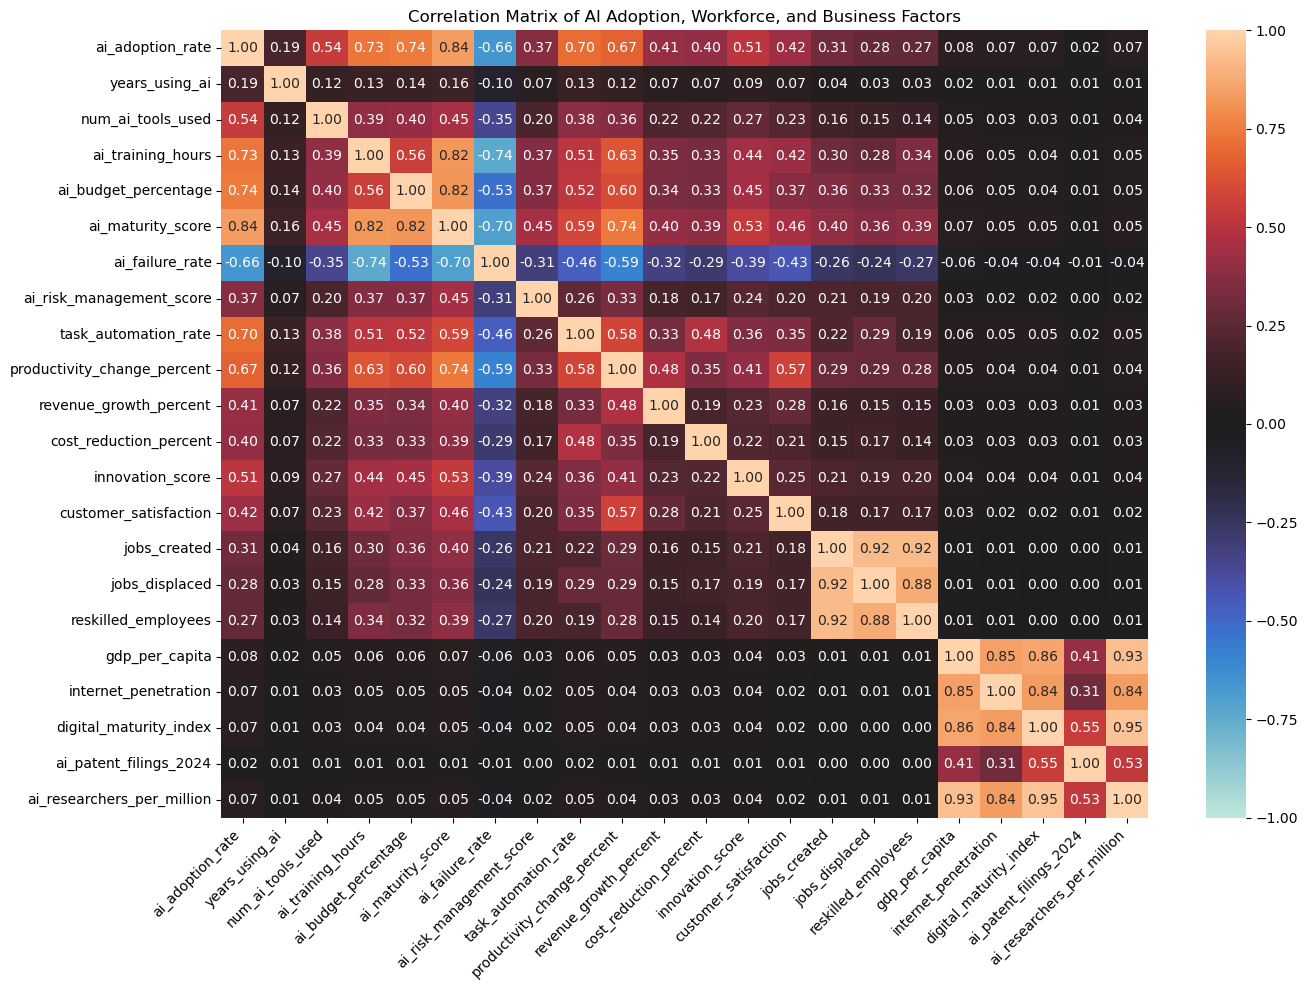

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    "Correlation Matrix of AI Adoption, Workforce, and Business Factors"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [25]:
corr_pairs = (
    corr_matrix
    .unstack()
    .reset_index()
)

corr_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Correlation"
]

corr_pairs = corr_pairs[
    corr_pairs["Variable 1"] != corr_pairs["Variable 2"]
]

corr_pairs.sort_values(
    "Correlation",
    ascending=False
).head(10)

,Variable 1,Variable 2,Correlation
439,digital_maturity_index,ai_researchers_per_million,0.952405
481,ai_researchers_per_million,digital_maturity_index,0.952405
395,gdp_per_capita,ai_researchers_per_million,0.932110
479,ai_researchers_per_million,gdp_per_capita,0.932110
323,jobs_created,jobs_displaced,0.923838
344,jobs_displaced,jobs_created,0.923838
324,jobs_created,reskilled_employees,0.923788
366,reskilled_employees,jobs_created,0.923788
367,reskilled_employees,jobs_displaced,0.876548
346,jobs_displaced,reskilled_employees,0.876548


Correlation Revelations!  
Digital maturity and ai research .95 - not surprising that countries with strong digital infrastructure has strong AI research system  
